In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

Saving car.data to car.data


In [3]:
column_names = [
    'buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety',
    'class'
]

df = pd.read_csv("car.data", names=column_names)

print(df.head())

  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [4]:
df.shape

(1728, 7)

In [5]:
df.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [7]:
print(df['class'].value_counts())

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    df[column] = encoder.fit_transform(df[column])

print(df.head())

   buying  maint  doors  persons  lug_boot  safety  class
0       3      3      0        0         2       1      2
1       3      3      0        0         2       2      2
2       3      3      0        0         2       0      2
3       3      3      0        0         1       1      2
4       3      3      0        0         1       2      2


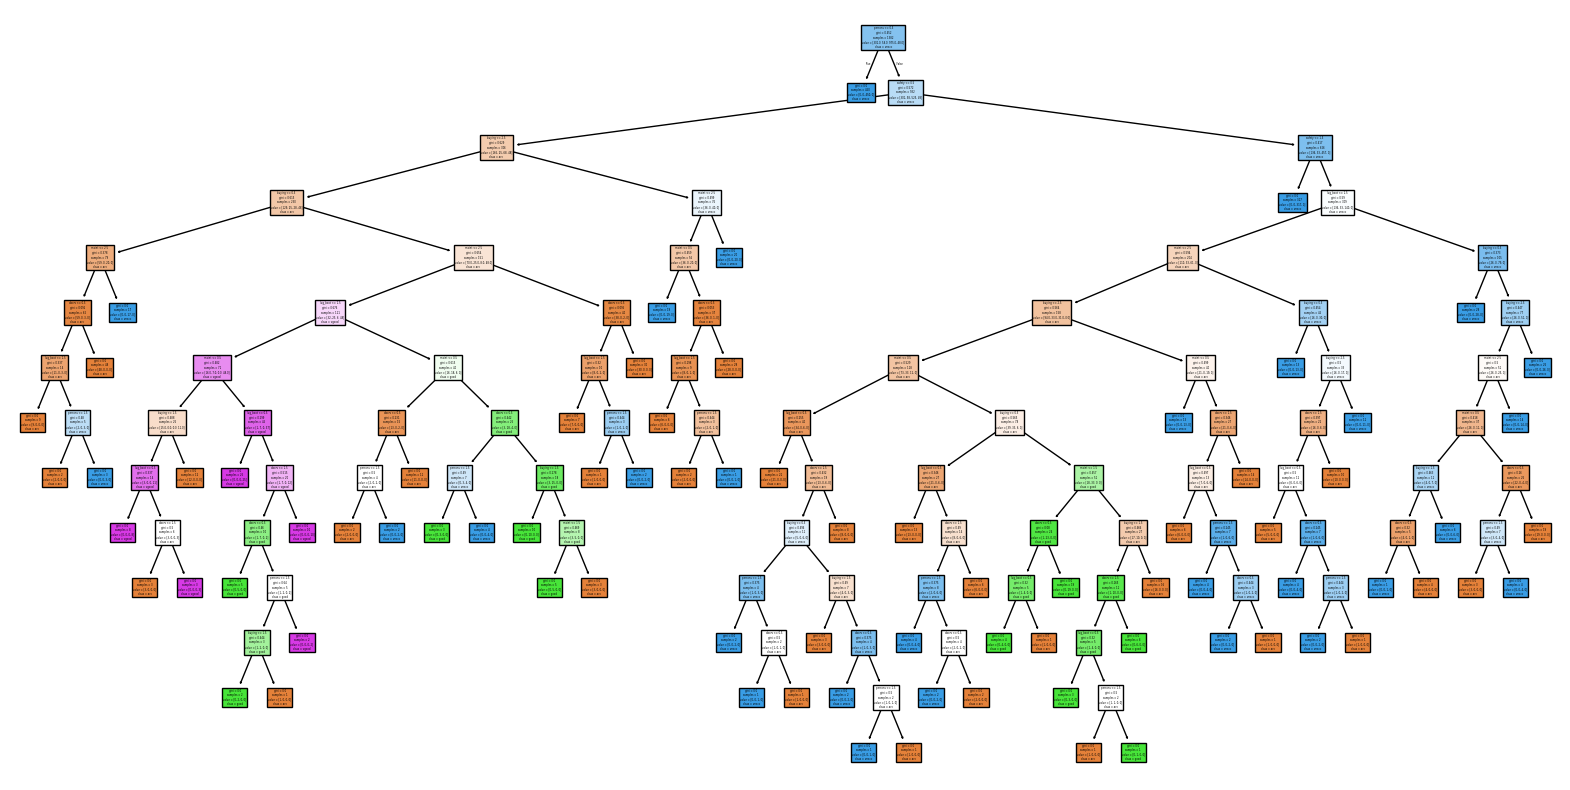

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    cart,
    feature_names=X.columns,
    class_names=['acc','good','unacc','vgood'],
    filled=True
)

plt.show()

In [9]:
X = df.drop('class', axis=1)
y = df['class']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

cart = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

cart.fit(X_train, y_train)

cart_pred = cart.predict(X_test)

print("CART Accuracy:", accuracy_score(y_test, cart_pred))

CART Accuracy: 0.9739884393063584


In [12]:
id3 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

id3.fit(X_train, y_train)

id3_pred = id3.predict(X_test)

print("ID3 Accuracy:", accuracy_score(y_test, id3_pred))

ID3 Accuracy: 0.9739884393063584


In [13]:
c45 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    random_state=42
)

c45.fit(X_train, y_train)

c45_pred = c45.predict(X_test)

print("C4.5 Accuracy:", accuracy_score(y_test, c45_pred))

C4.5 Accuracy: 0.8930635838150289
